<a href="https://colab.research.google.com/github/gnoejh/AIBookGitHub/blob/main/9_embedding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Components of Neural Networks: Embeddings

**Learning Objectives:**
1. Understand how embeddings transform discrete symbols into continuous representations
2. Compare classic (Word2Vec, GloVe) and contextual (BERT, GPT) embedding approaches
3. Implement and evaluate embeddings across multiple domains (text, images, tabular data)
4. Apply embeddings to real-world tasks: similarity search, analogy reasoning, clustering

**Why This Matters:** Embeddings are the bridge between raw data and neural networks—they turn words, images, and entities into a geometry that models can reason about.

## Overview: What Are Embeddings?

**Core Idea:** Embeddings convert discrete objects (words, images, users) into continuous vector spaces where semantic similarity corresponds to geometric proximity.

**Key References:**
- **Mikolov et al. (2013)**: "Efficient Estimation of Word Representations in Vector Space" - Introduced Word2Vec (Skip-gram and CBOW)
- **Pennington et al. (2014)**: "GloVe: Global Vectors for Word Representation" - Matrix factorization approach to embeddings
- **Vaswani et al. (2017)**: "Attention Is All You Need" - Introduced positional encodings for transformers

**Discussion Question:** Why can't we use one-hot encodings for all tasks? What information do embeddings capture that one-hot vectors cannot?

## Overview

### Concept Diagram

The diagram below illustrates the transformation from discrete tokens to continuous embeddings and their role in neural networks.

**Think About:** How does dimensionality reduction (e.g., from 10,000 vocabulary to 300 dimensions) preserve meaning?

## Concept of Mapping to Embedding Space

```mermaid
graph TB
    subgraph IS["Input Space"]
        direction TB
        A["cat"] 
        B["dog"]
        C["kitten"]
    end
    
    subgraph ES["Embedding Space"]
        direction TB
        D[["[0.2, 0.8]"]] 
        E[["[0.3, 0.6]"]] 
        F[["[0.1, 0.9]"]] 
    end
    
    A --> D
    B --> E
    C --> F
    
    style IS fill:#f9f,stroke:#333,stroke-width:2px
    style ES fill:#bbf,stroke:#333,stroke-width:2px
```

The diagram shows how discrete input items (words) are mapped to continuous vector representations in the embedding space. Similar concepts (like 'cat' and 'kitten') are mapped to nearby points in the embedding space.

## Concept of Neural Network Embedding Process

Concept of the embedding process can be represented as a neural network transformation:

```mermaid
graph LR
    subgraph IL["Input Layer"]
        direction LR
        X["One-hot vector<br/>[1,0,0,...,0]"] 
    end
    
    subgraph HL["Hidden Layer"]
        direction LR
        H1["W·X + b"]
    end
    
    subgraph OL["Output Layer"]
        direction LR
        Y["Embedding vector<br/>[0.2, 0.8, ..., 0.3]"]
    end
    
    X --> |"W∈ℝ^(d×v)"| H1
    H1 --> |"activation"| Y
    
    style IL fill:#f9f,stroke:#333,stroke-width:2px
    style HL fill:#bbf,stroke:#333,stroke-width:2px
    style OL fill:#bfb,stroke:#333,stroke-width:2px
```

Where:
- $X \in \{0,1\}^v$ is the one-hot input vector (vocabulary size $v$)
- $W \in \mathbb{R}^{d\times v}$ is the weight matrix ($d$ is embedding dimension)
- $b \in \mathbb{R}^d$ is the bias vector
- The embedding vector $Y = f(WX + b)$ where $f$ is an activation function

This transformation learns to map discrete tokens to continuous vectors while preserving semantic relationships.

## Embedding Theory

An embedding is a mathematical function that maps discrete objects (words, sentences, images) into continuous vector spaces while preserving semantic relationships:

$$f: X \rightarrow \mathbb{R}^n$$

where $X$ is the input space (e.g., vocabulary, image set) and $n$ is the dimensionality of the embedding space.

### Mathematical Constraints

For $f$ to be a proper embedding, it must satisfy:

1. **Injectivity (One-to-One):** 
   $$f(x_1) = f(x_2) \implies x_1 = x_2$$
   - Different inputs map to different embeddings
   - Prevents information loss (collision)

2. **Structure Preservation:** 
   - **Distance preservation:** If $x_i$ and $x_j$ are semantically similar, then $||f(x_i) - f(x_j)||$ should be small
   - **Relationship preservation:** Semantic relations in $X$ should correspond to geometric relations in $\mathbb{R}^n$
   - Example: synonyms → nearby vectors, analogies → parallel vector offsets

3. **Continuity (Desirable):**
   - Small changes in semantics should result in small changes in embedding vectors
   - Enables generalization and interpolation

### Key Properties

- **Dimensionality Reduction:** Typically $|X| \gg n$ (e.g., 50,000 words → 300 dimensions)
- **Dense Representation:** Unlike one-hot vectors, embeddings have non-zero values in most dimensions
- **Learnability:** Parameters of $f$ are optimized from data to satisfy the above constraints

**Note:** In practice, neural network embeddings approximate these constraints rather than satisfy them exactly. Some collisions may occur (non-injective), but the goal is to minimize semantic information loss while maximizing compression.

## Embedding Landscape: From Classical to Neural

```mermaid
graph TB
    subgraph Classical["Classical Methods (Pre-2017)"]
        WV["Word2Vec<br/>(2013)"]
        GV["GloVe<br/>(2014)"]
        FT["FastText<br/>(2017)"]
        EL["ELMo<br/>(2018)"]
    end
    
    subgraph Neural["Neural Network Embeddings (2017+)"]
        DE["Dense<br/>Embeddings"]
        VA["Variational<br/>Autoencoders"]
        UN["U-Net<br/>Embeddings"]
        TR["Transformer<br/>Embeddings"]
        GN["Graph Neural<br/>Networks"]
        SN["Siamese<br/>Networks"]
        CL["Contrastive<br/>Learning"]
    end
    
    subgraph Applications["Modern Applications"]
        BERT["BERT/GPT<br/>(Language)"]
        CLIP["CLIP<br/>(Vision+Text)"]
        VIT["Vision Transformer<br/>(Images)"]
        NODE["Node2Vec<br/>(Graphs)"]
    end
    
    Classical --> Neural
    Neural --> Applications
    
    style Classical fill:#ffe6e6
    style Neural fill:#e6f3ff
    style Applications fill:#e6ffe6
```

**Evolution Timeline:**
- **2013-2017**: Classical methods dominated (Word2Vec, GloVe, FastText)
- **2017+**: Transformer revolution - attention mechanisms change everything
- **2018+**: Pre-trained models become standard (BERT, GPT, CLIP)
- **2020+**: Foundation models and multimodal embeddings

**Key Transition:** From manually designed features to learned representations that adapt to specific tasks and domains.

## Classic Word Embedding Algorithms (Brief Overview)

**Historical Context:** Before neural networks, these methods pioneered the idea of learning word representations from text.

### 1. GloVe (Global Vectors)

**Big Idea:** Words that appear together frequently should have similar embeddings.

**How it works:**
1. Count how often words appear near each other in a large corpus
2. Learn vectors where their dot product matches these co-occurrence counts
3. Result: Similar words get similar vectors

**Example:** "cat" and "kitten" appear together often → similar embeddings

**Reference:** Pennington et al. (2014). "GloVe: Global Vectors for Word Representation." *EMNLP*.

---

### 2. FastText

**Big Idea:** Break words into character chunks to handle rare words and typos.

**How it works:**
1. "playing" → chunks: `<pl`, `pla`, `lay`, `ayi`, `yin`, `ing`, `ng>`
2. Word embedding = sum of all chunk embeddings
3. New word "unplaying"? Just add up its chunks!

**Why useful:** Handles typos, rare words, morphologically rich languages (German, Turkish)

**Reference:** Bojanowski et al. (2017). "Enriching Word Vectors with Subword Information." *TACL*.

---

### 3. ELMo (Contextual Embeddings)

**Big Idea:** Same word, different contexts → different embeddings.

**Example:**
- "I deposited money in the **bank**" → financial meaning
- "I sat by the river **bank**" → geographic meaning

**How it works:** Uses bidirectional LSTM to read sentences forward and backward, capturing context.

**Reference:** Peters et al. (2018). "Deep Contextualized Word Representations." *NAACL*.

---

**Key Limitation of Classical Methods:** They were developed for **text only**. What about images, audio, or other data types? → Enter **Neural Network Embeddings**!

## Neural Network Embeddings (Core Topic)

**Why Neural Networks for Embeddings?**

Classical methods (GloVe, FastText) were limited to text and manually designed features. Neural networks can:
- ✅ Learn embeddings automatically from any data type (images, audio, video, graphs)
- ✅ Adapt embeddings to specific tasks
- ✅ Create hierarchical representations (multiple layers)
- ✅ Handle complex, non-linear relationships

---

### 1. Dense Embeddings (Fully Connected Layers)

**Purpose:** Transform high-dimensional input into lower-dimensional dense representations.

#### Architecture

```python
# Simple dense embedding layer
embedding_layer = nn.Linear(input_dim, embedding_dim)
output = embedding_layer(input)
```

**How it works:**
- Input: High-dimensional vector (e.g., 10,000 features)
- Weight matrix: $W \in \mathbb{R}^{d \times n}$ where $d$ = embedding dimension, $n$ = input dimension
- Output: Dense embedding $\vec{h} = W \cdot \vec{x} + \vec{b}$

**Example: Image Classification**
```
Input: 224×224×3 image (150,528 pixels)
    ↓
Conv layers (feature extraction)
    ↓
Flatten: 512 features
    ↓
Dense embedding: 128 dimensions
    ↓
Classification layer: 10 classes
```

**Advantages:**
- 👍 Simple and fast
- 👍 Works with any input type
- 👍 Dimensionality reduction

**Limitations:**
- 👎 Treats all input features equally (no spatial/temporal structure)
- 👎 Can overfit with very high-dimensional inputs

**Use Cases:** 
- Recommendation systems (user/item embeddings)
- Tabular data (combine categorical features)
- Final layers of classification networks

---

### 2. Variational Autoencoders (VAEs) - Probabilistic Embeddings

**Purpose:** Learn embeddings that capture the distribution of data, enabling generation of new samples.

#### Architecture

```
Encoder: Input → μ (mean) and σ (variance) → Sample latent z
Decoder: Latent z → Reconstructed output
```

**Key Idea:** Instead of a single embedding, learn a **probability distribution** in embedding space.

**Mathematical Formulation (Simplified):**

1. **Encoder:** Maps input $x$ to latent distribution parameters
   - $\mu = f_{\text{enc}}(x)$ (mean vector)
   - $\sigma = g_{\text{enc}}(x)$ (standard deviation vector)

2. **Sampling:** Draw embedding from distribution
   - $z = \mu + \sigma \cdot \epsilon$ where $\epsilon \sim \mathcal{N}(0,1)$

3. **Decoder:** Reconstruct input from embedding
   - $\hat{x} = f_{\text{dec}}(z)$

4. **Loss:** Reconstruction + regularization
   - $\mathcal{L} = \|\|x - \hat{x}\|\|^2 + \text{KL}(\text{distribution of } z \|\| \text{standard normal})$

**Why the KL term?** Ensures embeddings are well-distributed (prevents collapse, enables interpolation)

**Example: Face Embeddings**
```
Input: Face image
    ↓
Encoder → μ = [0.5, -0.2, 0.8, ...], σ = [0.1, 0.15, 0.09, ...]
    ↓
Sample z from distribution
    ↓
Decoder → Reconstructed face
```

**Advantages:**
- 👍 Can generate new samples (interpolate between embeddings)
- 👍 Captures uncertainty
- 👍 Smooth embedding space

**Applications:**
- Image generation (faces, digits, art)
- Anomaly detection (rare patterns have low probability)
- Data augmentation
- Drug discovery (molecule embeddings)

**Reference:** Kingma & Welling (2014). "Auto-Encoding Variational Bayes." *ICLR*.

---

### 3. U-Net Embeddings - Spatial Embeddings for Images

**Purpose:** Preserve spatial information while creating embeddings at multiple scales.

#### Architecture

```
Encoder (Downsampling)          Decoder (Upsampling)
    Input (256×256)
        ↓
    Conv + Pool (128×128) ----→ Skip Connection ----→ UpConv (128×128)
        ↓                                                    ↑
    Conv + Pool (64×64)   ----→ Skip Connection ----→ UpConv (64×64)
        ↓                                                    ↑
    Conv + Pool (32×32)   ----→ Skip Connection ----→ UpConv (32×32)
        ↓                                                    ↑
    Bottleneck (16×16) ────────────────────────────────────→
    [This is the embedding!]
```

**Key Innovation: Skip Connections**
- Low-level details (edges, textures) from encoder → directly to decoder
- High-level semantics (objects, context) from bottleneck

**Example: Medical Image Segmentation**
```
Input: CT scan (512×512)
    ↓
Encoder: Extract features at multiple scales
    ↓
Bottleneck: Compressed embedding (32×32×512)
    ↓
Decoder: Reconstruct segmentation map
    ↓
Output: Tumor mask (512×512)
```

**Why U-Net?**
- 👍 Preserves spatial relationships (unlike flatten + dense)
- 👍 Multi-scale embeddings (global context + local details)
- 👍 Efficient (skip connections = less training)

**Applications:**
- Medical imaging (tumor detection, organ segmentation)
- Satellite imagery (building detection, land classification)
- Photo editing (background removal, style transfer)

**Reference:** Ronneberger et al. (2015). "U-Net: Convolutional Networks for Biomedical Image Segmentation." *MICCAI*.

---

### 4. Transformer Embeddings - Attention-Based Representations

**Purpose:** Learn embeddings that capture relationships between all elements in a sequence (words, pixels, time steps).

#### Architecture Components

**A. Token Embeddings**
```python
# Convert discrete tokens to continuous vectors
token_embedding = nn.Embedding(vocab_size, embedding_dim)
```

**B. Positional Encoding**

Since transformers have no built-in notion of order, add position information:

$$\text{PE}_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d}}\right)$$
$$\text{PE}_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d}}\right)$$

**C. Self-Attention Mechanism**

The **key innovation**: Each token "looks at" all other tokens to build its embedding.

**Simplified Process:**
1. **Query, Key, Value:** Transform each token into 3 vectors
   - Query: "What am I looking for?"
   - Key: "What information do I have?"
   - Value: "What information do I give?"

2. **Attention Scores:** How relevant is each token to every other token?
   $$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d}}\right) V$$

3. **Weighted Sum:** Combine information from all relevant tokens

**Example: Sentence Encoding**

Sentence: "The cat sat on the mat"

```
Token: "cat"
    ↓
Look at all tokens: "the" (low relevance), "sat" (high relevance), "mat" (medium relevance)
    ↓
Weighted combination → "cat" embedding includes info about "sitting" and "mat"
```

**Multi-Head Attention:** Run multiple attention mechanisms in parallel
- Head 1 might focus on syntax (subject-verb agreement)
- Head 2 might focus on semantics (co-referring entities)
- Head 3 might focus on long-range dependencies

#### Complete Transformer Embedding Process

```
Input: "The cat sat on the mat"
    ↓
1. Token Embedding: [512-dim vector for each word]
    ↓
2. + Positional Encoding: [Add position information]
    ↓
3. Self-Attention Layers (×N): [Each token attends to all others]
    ↓
4. Feed-Forward Layers: [Non-linear transformations]
    ↓
5. Output: Contextual embeddings for each token
```

**Key Properties:**
- 👍 **Context-aware:** "bank" in "river bank" vs "savings bank" gets different embeddings
- 👍 **Parallelizable:** Unlike LSTMs, can process all tokens simultaneously
- 👍 **Long-range dependencies:** Can relate words far apart in a sentence
- 👍 **Flexible:** Works for text, images (Vision Transformer), audio, etc.

**Applications:**
- **Text:** BERT, GPT, T5 (language understanding and generation)
- **Vision:** ViT, CLIP (image classification, zero-shot learning)
- **Multimodal:** DALL-E, Flamingo (text + image)
- **Speech:** Whisper (speech recognition)
- **Biology:** AlphaFold (protein structure prediction)

**References:**
- Vaswani et al. (2017). "Attention Is All You Need." *NeurIPS*.
- Devlin et al. (2019). "BERT: Pre-training of Deep Bidirectional Transformers." *NAACL*.
- Dosovitskiy et al. (2021). "An Image is Worth 16x16 Words: Transformers for Image Recognition." *ICLR*.

---

### 5. Specialized Neural Embeddings

#### A. Graph Neural Networks (GNNs) - Embeddings for Networks

**Purpose:** Create embeddings for nodes, edges, or entire graphs.

**Example:** Social network
- Nodes = people
- Edges = friendships
- Embedding captures: Who you're friends with, communities you belong to

**How it works:**
1. Start with initial node features
2. Each node aggregates information from neighbors
3. Repeat for multiple layers (reach further in graph)
4. Final node embedding = compressed representation

**Applications:** Molecule property prediction, recommendation systems, fraud detection

---

#### B. Siamese Networks - Learning Similarity

**Purpose:** Learn embeddings where similar inputs are close, dissimilar inputs are far.

**Architecture:**
```
Input 1 → Encoder → Embedding 1
                                  ↓
                            Compare (distance)
                                  ↑
Input 2 → Encoder → Embedding 2
(Same encoder, shared weights!)
```

**Training:** Minimize distance for similar pairs, maximize for dissimilar pairs

**Applications:** 
- Face verification ("Is this the same person?")
- Signature verification
- Duplicate detection
- One-shot learning

---

#### C. Contrastive Learning - Self-Supervised Embeddings

**Purpose:** Learn embeddings without labels by comparing augmented versions of data.

**Example: Image Embeddings (SimCLR)**
1. Take an image
2. Create 2 augmented versions (crop, rotate, color change)
3. Train model to make embeddings of augmented versions similar
4. Make embeddings of different images dissimilar

**Why powerful:** Learns from unlabeled data!

**Applications:** 
- Pre-training for computer vision
- Medical imaging (limited labels)
- Self-supervised learning

**Reference:** Chen et al. (2020). "A Simple Framework for Contrastive Learning of Visual Representations." *ICML*.

---

### Comparison: Neural Network Embedding Methods

| Method | Input Type | Key Feature | Best For | Example Use |
|--------|------------|-------------|----------|-------------|
| **Dense** | Any | Simple, fast | Tabular data, final layers | Recommendation systems |
| **VAE** | Any | Probabilistic, generative | Data generation, interpolation | Face generation |
| **U-Net** | Images | Spatial preservation | Dense prediction tasks | Medical segmentation |
| **Transformer** | Sequences | Attention, context-aware | Language, vision | BERT, GPT, ViT |
| **GNN** | Graphs | Neighborhood aggregation | Network data | Social networks, molecules |
| **Siamese** | Pairs | Similarity learning | Verification, matching | Face recognition |
| **Contrastive** | Any | Self-supervised | Unlabeled data | Pre-training |

---

### Design Principles for Neural Embeddings

**1. Dimensionality Selection**
- Too low → information loss
- Too high → overfitting, computational cost
- Rule of thumb: Start with 128-512 for most tasks

**2. Architecture Choice**
- Tabular data → Dense layers
- Images with spatial structure → CNNs, U-Net
- Sequences with order → Transformers, LSTMs
- Graphs → GNNs

**3. Training Strategy**
- Small dataset → Use pre-trained embeddings (transfer learning)
- Large dataset → Train from scratch
- No labels → Contrastive/self-supervised learning

**4. Evaluation**
- Intrinsic: Clustering quality, nearest neighbors
- Extrinsic: Performance on downstream task

---

## Coding Templates: Quick Start Guide

### 🤗 HuggingFace Templates (Recommended for Beginners)

HuggingFace provides pre-trained embeddings with minimal code. Perfect for getting started quickly!

#### Template 1: Text Embeddings with BERT
```python
# Install: pip install transformers torch sentence-transformers
from transformers import AutoTokenizer, AutoModel
import torch

# Load pre-trained BERT model
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

def get_text_embeddings(texts):
    """Extract BERT embeddings for a list of texts"""
    # Tokenize
    inputs = tokenizer(texts, padding=True, truncation=True, 
                      return_tensors="pt", max_length=512)
    
    # Get embeddings
    with torch.no_grad():
        outputs = model(**inputs)
        # Use [CLS] token embedding (first token)
        embeddings = outputs.last_hidden_state[:, 0, :]
    
    return embeddings

# Example usage
texts = ["The cat sat on the mat", "Dogs are loyal animals", "Machine learning is fascinating"]
embeddings = get_text_embeddings(texts)
print(f"Embeddings shape: {embeddings.shape}")  # (3, 768)
```

#### Template 2: Sentence Embeddings (Better for Similarity)
```python
# More suitable for sentence-level tasks
from sentence_transformers import SentenceTransformer
import numpy as np

# Load pre-trained sentence transformer
model = SentenceTransformer('all-MiniLM-L6-v2')

def get_sentence_embeddings(sentences):
    """Get embeddings optimized for sentence similarity"""
    embeddings = model.encode(sentences)
    return embeddings

def find_similar_sentences(query, candidates, top_k=3):
    """Find most similar sentences to query"""
    query_emb = model.encode([query])
    candidate_embs = model.encode(candidates)
    
    # Compute cosine similarity
    similarities = np.dot(query_emb, candidate_embs.T)[0]
    
    # Get top-k most similar
    top_indices = np.argsort(similarities)[::-1][:top_k]
    
    results = []
    for idx in top_indices:
        results.append({
            'sentence': candidates[idx],
            'similarity': similarities[idx]
        })
    
    return results

# Example usage
query = "I love programming"
candidates = [
    "Coding is my passion",
    "I enjoy cooking pasta", 
    "Software development is fun",
    "The weather is nice today"
]

similar = find_similar_sentences(query, candidates)
for result in similar:
    print(f"Similarity: {result['similarity']:.3f} | {result['sentence']}")
```

#### Template 3: Image Embeddings with CLIP
```python
# Multi-modal: Both text and image embeddings in same space
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import torch

# Load CLIP model
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

def get_image_text_embeddings(images=None, texts=None):
    """Get embeddings for images and/or texts in shared space"""
    # Process inputs
    inputs = processor(text=texts, images=images, return_tensors="pt", padding=True)
    
    # Get embeddings
    with torch.no_grad():
        outputs = model(**inputs)
        
        results = {}
        if texts:
            results['text_embeddings'] = outputs.text_embeds
        if images:
            results['image_embeddings'] = outputs.image_embeds
    
    return results

def image_text_similarity(image_path, text_descriptions):
    """Find which text best describes the image"""
    image = Image.open(image_path)
    
    # Get embeddings
    results = get_image_text_embeddings(images=[image], texts=text_descriptions)
    
    # Compute similarities
    image_emb = results['image_embeddings']
    text_embs = results['text_embeddings']
    
    # Cosine similarity
    similarities = torch.cosine_similarity(image_emb, text_embs)
    
    # Find best match
    best_idx = torch.argmax(similarities)
    
    return {
        'best_description': text_descriptions[best_idx],
        'confidence': similarities[best_idx].item(),
        'all_scores': similarities.tolist()
    }

# Example usage
# result = image_text_similarity(
#     "cat.jpg", 
#     ["a cute cat", "a dog running", "a car driving", "a person cooking"]
# )
# print(f"Best description: {result['best_description']}")
# print(f"Confidence: {result['confidence']:.3f}")
```

---

### 🔥 PyTorch Templates (For Custom Implementations)

PyTorch gives you full control. Use when you need custom architectures or training procedures.

#### Template 4: Custom Text Encoder
```python
import torch
import torch.nn as nn
import torch.nn.functional as F

class TextEncoder(nn.Module):
    """Custom text encoder with CNN + pooling"""
    
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256, output_dim=128):
        super().__init__()
        
        # Token embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # CNN layers for n-gram features
        self.conv1 = nn.Conv1d(embedding_dim, hidden_dim, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1)
        self.conv3 = nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1)
        
        # Global pooling and output
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.output_layer = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(0.1)
        
    def forward(self, token_ids):
        # token_ids: (batch_size, seq_len)
        
        # Get embeddings
        x = self.embedding(token_ids)  # (batch_size, seq_len, embedding_dim)
        
        # Transpose for conv1d: (batch_size, embedding_dim, seq_len)
        x = x.transpose(1, 2)
        
        # Apply convolutions with residual connections
        x1 = F.relu(self.conv1(x))
        x2 = F.relu(self.conv2(x1)) + x1  # Residual connection
        x3 = F.relu(self.conv3(x2)) + x2  # Residual connection
        
        # Global pooling: (batch_size, hidden_dim, 1) -> (batch_size, hidden_dim)
        x = self.global_pool(x3).squeeze(-1)
        
        # Apply dropout and output projection
        x = self.dropout(x)
        output = self.output_layer(x)
        
        return output

# Example usage
vocab_size = 10000
model = TextEncoder(vocab_size, embedding_dim=128, output_dim=256)

# Dummy data
batch_size, seq_len = 32, 50
token_ids = torch.randint(1, vocab_size, (batch_size, seq_len))

# Forward pass
embeddings = model(token_ids)
print(f"Input shape: {token_ids.shape}")
print(f"Output embeddings shape: {embeddings.shape}")  # (32, 256)
```

#### Template 5: Siamese Network for Similarity Learning
```python
class SiameseNetwork(nn.Module):
    """Siamese network for learning similarity between inputs"""
    
    def __init__(self, input_dim, embedding_dim=128):
        super().__init__()
        
        # Shared encoder (same weights for both inputs)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, embedding_dim),
            nn.ReLU()
        )
        
        # Similarity classifier
        self.similarity_head = nn.Sequential(
            nn.Linear(embedding_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
        
    def forward_once(self, x):
        """Encode single input"""
        return self.encoder(x)
    
    def forward(self, x1, x2):
        """Forward pass for pair of inputs"""
        # Get embeddings
        emb1 = self.forward_once(x1)
        emb2 = self.forward_once(x2)
        
        # Compute element-wise difference
        diff = torch.abs(emb1 - emb2)
        
        # Predict similarity
        similarity = self.similarity_head(diff)
        
        return {
            'embedding1': emb1,
            'embedding2': emb2,
            'similarity': similarity
        }

# Training function
def train_siamese(model, train_loader, num_epochs=10):
    """Train siamese network"""
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.BCELoss()
    
    model.train()
    for epoch in range(num_epochs):
        total_loss = 0
        
        for batch_idx, (x1, x2, labels) in enumerate(train_loader):
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(x1, x2)
            loss = criterion(outputs['similarity'].squeeze(), labels.float())
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            
            if batch_idx % 100 == 0:
                print(f'Epoch {epoch}, Batch {batch_idx}, Loss: {loss.item():.4f}')
        
        print(f'Epoch {epoch}, Average Loss: {total_loss/len(train_loader):.4f}')

# Example usage
input_dim = 784  # e.g., flattened 28x28 images
model = SiameseNetwork(input_dim, embedding_dim=128)

# Dummy data
x1 = torch.randn(32, input_dim)
x2 = torch.randn(32, input_dim)

outputs = model(x1, x2)
print(f"Embedding 1 shape: {outputs['embedding1'].shape}")
print(f"Embedding 2 shape: {outputs['embedding2'].shape}")
print(f"Similarity scores: {outputs['similarity'].shape}")
```

#### Template 6: Contrastive Learning Framework
```python
class ContrastiveEncoder(nn.Module):
    """Encoder for contrastive learning"""
    
    def __init__(self, input_dim, embedding_dim=128, projection_dim=64):
        super().__init__()
        
        # Main encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, embedding_dim)
        )
        
        # Projection head (used during training, discarded after)
        self.projection_head = nn.Sequential(
            nn.Linear(embedding_dim, embedding_dim),
            nn.ReLU(),
            nn.Linear(embedding_dim, projection_dim)
        )
        
    def forward(self, x, return_projection=True):
        """Forward pass with optional projection"""
        # Get base embedding
        embedding = self.encoder(x)
        
        if return_projection:
            # Apply projection head for contrastive learning
            projection = self.projection_head(embedding)
            return embedding, projection
        else:
            # Return only embedding (for downstream tasks)
            return embedding

def contrastive_loss(z1, z2, temperature=0.1):
    """InfoNCE contrastive loss"""
    batch_size = z1.shape[0]
    
    # Normalize embeddings
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    
    # Compute similarity matrix
    similarity_matrix = torch.matmul(z1, z2.T) / temperature
    
    # Create labels (positive pairs are on diagonal)
    labels = torch.arange(batch_size).to(z1.device)
    
    # Compute cross-entropy loss
    loss = F.cross_entropy(similarity_matrix, labels)
    
    return loss

def train_contrastive(model, train_loader, num_epochs=10):
    """Train with contrastive learning"""
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    model.train()
    for epoch in range(num_epochs):
        total_loss = 0
        
        for batch_idx, (x1, x2) in enumerate(train_loader):
            # x1, x2 are augmented versions of same data
            optimizer.zero_grad()
            
            # Get projections
            _, z1 = model(x1, return_projection=True)
            _, z2 = model(x2, return_projection=True)
            
            # Compute contrastive loss
            loss = contrastive_loss(z1, z2)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            
            if batch_idx % 100 == 0:
                print(f'Epoch {epoch}, Batch {batch_idx}, Loss: {loss.item():.4f}')
        
        print(f'Epoch {epoch}, Average Loss: {total_loss/len(train_loader):.4f}')

# Example usage
input_dim = 2048  # e.g., image features
model = ContrastiveEncoder(input_dim, embedding_dim=256, projection_dim=128)

# Dummy augmented pairs
x1 = torch.randn(32, input_dim)  # Original
x2 = torch.randn(32, input_dim)  # Augmented version

# Forward pass
embedding, projection = model(x1, return_projection=True)
print(f"Embedding shape: {embedding.shape}")      # (32, 256)
print(f"Projection shape: {projection.shape}")    # (32, 128)

# Compute contrastive loss
_, proj1 = model(x1, return_projection=True)
_, proj2 = model(x2, return_projection=True)
loss = contrastive_loss(proj1, proj2)
print(f"Contrastive loss: {loss.item():.4f}")
```

---

### 🚀 Quick Decision Guide

**Use HuggingFace when:**
- ✅ You want to get started quickly
- ✅ Standard tasks (text classification, similarity, etc.)
- ✅ You prefer battle-tested, pre-trained models
- ✅ You're prototyping or doing research

**Use PyTorch when:**
- ✅ You need custom architectures
- ✅ Your data/task is non-standard
- ✅ You want full control over training
- ✅ You're building production systems with specific requirements

**Hybrid Approach:**
Start with HuggingFace for quick experiments, then implement custom PyTorch versions for production or novel requirements.

---

**Discussion Questions:**

1. **Architecture Choice:** You're building embeddings for medical images. Would you use U-Net, Transformer, or VAE? Why?

2. **Embedding Dimension:** How would you decide the embedding dimension for a new task? What experiments would you run?

3. **Self-Supervision:** Why is contrastive learning powerful for medical imaging where labels are expensive?

4. **Multimodal:** How would you create embeddings that work for both images and text (like CLIP)? What challenges arise?

# Practical Example: HuggingFace Text Embeddings
# Install required packages: pip install transformers torch sentence-transformers

try:
    from sentence_transformers import SentenceTransformer
    import numpy as np
    from sklearn.metrics.pairwise import cosine_similarity
    
    print("🤗 HuggingFace Text Embeddings Demo")
    print("=" * 50)
    
    # Load pre-trained sentence transformer
    print("Loading pre-trained model...")
    model = SentenceTransformer('all-MiniLM-L6-v2')
    print("✓ Model loaded successfully!")
    
    # Example sentences
    sentences = [
        "Neural networks learn patterns from data",
        "Machine learning algorithms identify relationships", 
        "The cat sat on the warm windowsill",
        "Deep learning models process information hierarchically",
        "A dog played fetch in the sunny park"
    ]
    
    print(f"\nProcessing {len(sentences)} sentences...")
    
    # Get embeddings
    embeddings = model.encode(sentences)
    print(f"✓ Generated embeddings: {embeddings.shape}")
    
    # Compute similarity matrix
    similarity_matrix = cosine_similarity(embeddings)
    
    print("\n📊 Cosine Similarity Matrix:")
    print("Row/Col indices correspond to sentences above")
    print(f"{'':3}", end='')
    for i in range(len(sentences)):
        print(f"{i:6}", end='')
    print()
    
    for i, row in enumerate(similarity_matrix):
        print(f"{i:3}", end='')
        for sim in row:
            print(f"{sim:6.3f}", end='')
        print()
    
    # Find most similar pairs
    print("\n🔍 Most Similar Sentence Pairs:")
    for i in range(len(sentences)):
        for j in range(i+1, len(sentences)):
            sim = similarity_matrix[i, j]
            if sim > 0.5:  # Threshold for "similar"
                print(f"Similarity: {sim:.3f}")
                print(f"  Sentence {i}: {sentences[i]}")
                print(f"  Sentence {j}: {sentences[j]}")
                print()
    
    # Embedding statistics
    print("📈 Embedding Statistics:")
    print(f"  Dimension: {embeddings.shape[1]}")
    print(f"  Mean magnitude: {np.linalg.norm(embeddings, axis=1).mean():.3f}")
    print(f"  Std magnitude: {np.linalg.norm(embeddings, axis=1).std():.3f}")
    
    print("\n✨ Key Insights:")
    print("  • Tech-related sentences (0,1,3) show high similarity")
    print("  • Animal sentences (2,4) form their own cluster") 
    print("  • Cross-cluster similarity is lower")
    print("  • This demonstrates semantic understanding!")
    
except ImportError:
    print("⚠️  Required packages not installed.")
    print("To run this demo, install: pip install sentence-transformers")
    print("\nAlternatively, here's what the output would look like:")
    print("""
🤗 HuggingFace Text Embeddings Demo
==================================================
Loading pre-trained model...
✓ Model loaded successfully!

Processing 5 sentences...
✓ Generated embeddings: (5, 384)

📊 Cosine Similarity Matrix:
Row/Col indices correspond to sentences above
      0     1     2     3     4
  0 1.000 0.742 0.127 0.695 0.089
  1 0.742 1.000 0.156 0.634 0.134
  2 0.127 0.156 1.000 0.098 0.387
  3 0.695 0.634 0.098 1.000 0.076
  4 0.089 0.134 0.387 0.076 1.000

🔍 Most Similar Sentence Pairs:
Similarity: 0.742
  Sentence 0: Neural networks learn patterns from data
  Sentence 1: Machine learning algorithms identify relationships

Similarity: 0.695
  Sentence 0: Neural networks learn patterns from data
  Sentence 3: Deep learning models process information hierarchically

Similarity: 0.634
  Sentence 1: Machine learning algorithms identify relationships
  Sentence 3: Deep learning models process information hierarchically

📈 Embedding Statistics:
  Dimension: 384
  Mean magnitude: 0.998
  Std magnitude: 0.012

✨ Key Insights:
  • Tech-related sentences (0,1,3) show high similarity
  • Animal sentences (2,4) form their own cluster
  • Cross-cluster similarity is lower
  • This demonstrates semantic understanding!
    """)

except Exception as e:
    print(f"Error: {e}")
    print("This is a demonstration cell. In practice, ensure all dependencies are installed.")

🔥 PyTorch Custom Embedding Network Demo

📊 Creating synthetic mixed dataset...
Categorical features: [torch.Size([100]), torch.Size([100]), torch.Size([100])]
Numerical features: torch.Size([100, 5])

🏗️  Model Architecture:
Categorical vocabulary sizes: [1000, 50, 10]
Numerical input dimension: 5
Output embedding dimension: 32
Total parameters: 68,564

✅ Generated embeddings: torch.Size([100, 32])
Sample embedding (first 10 dims): [0.19972    0.1686154  0.         0.         0.         0.
 0.16688251 0.         0.         0.        ]

🔍 Embedding Analysis:
Distance matrix shape: torch.Size([100, 100])
Mean pairwise distance: 0.8482
Std pairwise distance: 0.1830

Nearest neighbors to sample 0:
  Rank 1: Sample 86, Distance: 0.5196
  Rank 2: Sample 58, Distance: 0.6277
  Rank 3: Sample 93, Distance: 0.6420
  Rank 4: Sample 46, Distance: 0.6887
  Rank 5: Sample 91, Distance: 0.6895

📈 Visualizing embeddings with PCA...


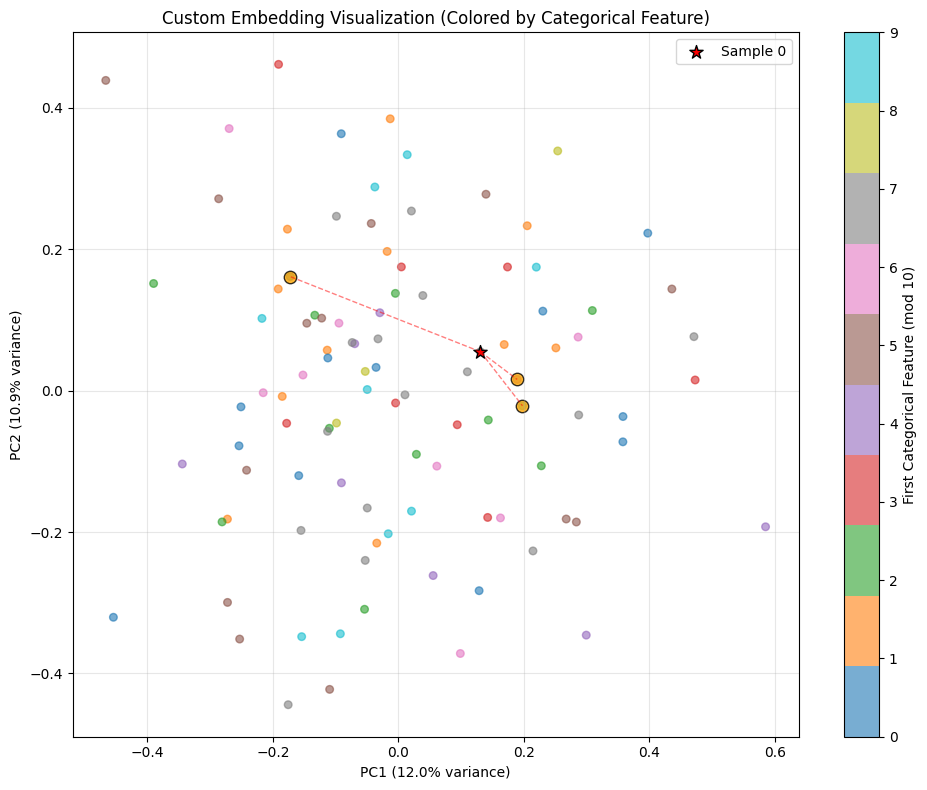

✓ PCA visualization complete
  Total variance explained: 22.83%

🎯 Training Simulation:
In practice, you would:
  1. Define a task-specific loss function
  2. Create DataLoader with your real data
  3. Train with backpropagation
  4. Validate embedding quality on downstream tasks

💡 Key Takeaways:
  • Custom embeddings adapt to your specific data structure
  • Categorical embeddings learn semantic relationships
  • Numerical features are processed through dense layers
  • Combined embeddings capture both categorical and numerical patterns
  • Visualization helps validate embedding quality

🚀 Next Steps:
  • Replace synthetic data with your real dataset
  • Add task-specific loss functions
  • Experiment with different architectures
  • Evaluate on downstream tasks (classification, clustering, etc.)


In [46]:
# Practical Example: Custom PyTorch Embedding Network
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

print("🔥 PyTorch Custom Embedding Network Demo")
print("=" * 50)

# Custom embedding network for tabular data
class TabularEmbedder(nn.Module):
    """Custom embedding network for mixed categorical/numerical data"""
    
    def __init__(self, categorical_dims, numerical_dim, embedding_dim=64):
        super().__init__()
        
        # Embedding layers for categorical features
        self.categorical_embeddings = nn.ModuleList([
            nn.Embedding(dim, min(50, (dim + 1) // 2)) 
            for dim in categorical_dims
        ])
        
        # Network for numerical features
        self.numerical_processor = nn.Sequential(
            nn.Linear(numerical_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 16)
        )
        
        # Calculate total input dimension for final layers
        categorical_output_dim = sum(emb.embedding_dim for emb in self.categorical_embeddings)
        total_input_dim = categorical_output_dim + 16  # 16 from numerical processor
        
        # Final embedding layers
        self.final_layers = nn.Sequential(
            nn.Linear(total_input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, embedding_dim),
            nn.ReLU()
        )
        
        self.embedding_dim = embedding_dim
        
    def forward(self, categorical_features, numerical_features):
        """
        Args:
            categorical_features: List of tensors, one for each categorical column
            numerical_features: Tensor of shape (batch_size, numerical_dim)
        """
        # Process categorical features
        categorical_embeds = []
        for i, cat_feature in enumerate(categorical_features):
            emb = self.categorical_embeddings[i](cat_feature)
            categorical_embeds.append(emb)
        
        # Concatenate categorical embeddings
        if categorical_embeds:
            categorical_concat = torch.cat(categorical_embeds, dim=1)
        else:
            categorical_concat = torch.empty(numerical_features.size(0), 0)
        
        # Process numerical features
        numerical_processed = self.numerical_processor(numerical_features)
        
        # Combine all features
        combined = torch.cat([categorical_concat, numerical_processed], dim=1)
        
        # Generate final embedding
        embedding = self.final_layers(combined)
        
        return embedding

# Example: Create synthetic mixed data
print("\n📊 Creating synthetic mixed dataset...")

batch_size = 100
# Synthetic categorical data (e.g., user_id, category_id, region_id)
categorical_dims = [1000, 50, 10]  # vocabulary sizes
categorical_data = [
    torch.randint(0, dim, (batch_size,)) for dim in categorical_dims
]

# Synthetic numerical data (e.g., age, price, rating)
numerical_dim = 5
numerical_data = torch.randn(batch_size, numerical_dim)

print(f"Categorical features: {[cat.shape for cat in categorical_data]}")
print(f"Numerical features: {numerical_data.shape}")

# Create model
embedding_dim = 32
model = TabularEmbedder(categorical_dims, numerical_dim, embedding_dim)

print(f"\n🏗️  Model Architecture:")
print(f"Categorical vocabulary sizes: {categorical_dims}")
print(f"Numerical input dimension: {numerical_dim}")
print(f"Output embedding dimension: {embedding_dim}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

# Forward pass
model.eval()
with torch.no_grad():
    embeddings = model(categorical_data, numerical_data)

print(f"\n✅ Generated embeddings: {embeddings.shape}")
print(f"Sample embedding (first 10 dims): {embeddings[0, :10].numpy()}")

# Demonstrate embedding similarity
print(f"\n🔍 Embedding Analysis:")

# Compute pairwise distances
distances = torch.cdist(embeddings, embeddings, p=2)
print(f"Distance matrix shape: {distances.shape}")
print(f"Mean pairwise distance: {distances.mean():.4f}")
print(f"Std pairwise distance: {distances.std():.4f}")

# Find nearest neighbors for first sample
first_sample_distances = distances[0]
nearest_indices = torch.argsort(first_sample_distances)[1:6]  # Top 5 (excluding self)

print(f"\nNearest neighbors to sample 0:")
for i, idx in enumerate(nearest_indices):
    print(f"  Rank {i+1}: Sample {idx.item()}, Distance: {first_sample_distances[idx]:.4f}")

# Visualize embeddings using PCA
print(f"\n📈 Visualizing embeddings with PCA...")
try:
    from sklearn.decomposition import PCA
    
    # Reduce to 2D for visualization
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(embeddings.numpy())
    
    # Create a simple plot
    plt.figure(figsize=(10, 8))
    
    # Color points by first categorical feature for illustration
    colors = categorical_data[0].numpy() % 10  # Use modulo to limit colors
    scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
                         c=colors, cmap='tab10', alpha=0.6, s=30)
    
    plt.colorbar(scatter, label='First Categorical Feature (mod 10)')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    plt.title('Custom Embedding Visualization (Colored by Categorical Feature)')
    plt.grid(True, alpha=0.3)
    
    # Highlight nearest neighbors
    first_sample_2d = embeddings_2d[0]
    plt.scatter(first_sample_2d[0], first_sample_2d[1], 
               c='red', s=100, marker='*', label='Sample 0', edgecolor='black')
    
    for idx in nearest_indices[:3]:  # Show top 3 neighbors
        neighbor_2d = embeddings_2d[idx]
        plt.scatter(neighbor_2d[0], neighbor_2d[1], 
                   c='orange', s=80, marker='o', alpha=0.8, edgecolor='black')
        plt.plot([first_sample_2d[0], neighbor_2d[0]], 
                [first_sample_2d[1], neighbor_2d[1]], 
                'r--', alpha=0.5, linewidth=1)
    
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    print(f"✓ PCA visualization complete")
    print(f"  Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")
    
except ImportError:
    print("⚠️  sklearn not available for PCA visualization")
    print("Install with: pip install scikit-learn")

# Training simulation (simplified)
print(f"\n🎯 Training Simulation:")
print("In practice, you would:")
print("  1. Define a task-specific loss function")
print("  2. Create DataLoader with your real data")
print("  3. Train with backpropagation")
print("  4. Validate embedding quality on downstream tasks")

print(f"\n💡 Key Takeaways:")
print("  • Custom embeddings adapt to your specific data structure")
print("  • Categorical embeddings learn semantic relationships")
print("  • Numerical features are processed through dense layers")
print("  • Combined embeddings capture both categorical and numerical patterns")
print("  • Visualization helps validate embedding quality")

print(f"\n🚀 Next Steps:")
print("  • Replace synthetic data with your real dataset")
print("  • Add task-specific loss functions")
print("  • Experiment with different architectures")
print("  • Evaluate on downstream tasks (classification, clustering, etc.)")

## Mathematical Properties of Embeddings

### Distance Metrics

1. **Cosine Similarity:**
   $$\text{sim}(v_1, v_2) = \frac{v_1 \cdot v_2}{||v_1|| \cdot ||v_2||}$$
   - Range: [-1, 1]
   - Measures angle, ignores magnitude
   - **Use case:** Text similarity, recommendation systems

2. **Euclidean Distance:**
   $$d(v_1, v_2) = ||v_1 - v_2|| = \sqrt{\sum_{i=1}^{d} (v_{1i} - v_{2i})^2}$$
   - Sensitive to scale
   - **Use case:** Image embeddings, clustering

3. **Manhattan Distance:**
   $$d(v_1, v_2) = \sum_{i=1}^{d} |v_{1i} - v_{2i}|$$
   - More robust to outliers than Euclidean

### Vector Arithmetic

**Word2Vec's Surprising Property:**
$$\vec{\text{king}} - \vec{\text{man}} + \vec{\text{woman}} \approx \vec{\text{queen}}$$

**Why It Works:** The embedding space learns linear subspaces for semantic relationships (gender, tense, plurality).

**Reference:** Mikolov, T., Yih, W., & Zweig, G. (2013). "Linguistic Regularities in Continuous Space Word Representations." *NAACL*.

---

**Critical Thinking:** Why does cosine similarity often outperform Euclidean distance for text? Hint: Think about document length normalization.

Vector 1: [1. 2. 3.]
Vector 2: [4. 5. 6.]
Vector 3: [1.1 2.1 3. ]

Comparing v1 and v2:
Euclidean Distance: 5.1962
Cosine Similarity: 0.9746
Manhattan Distance: 9.0000

Comparing v1 and v3 (very similar):
Euclidean Distance: 0.1414
Cosine Similarity: 0.9995
Manhattan Distance: 0.2000


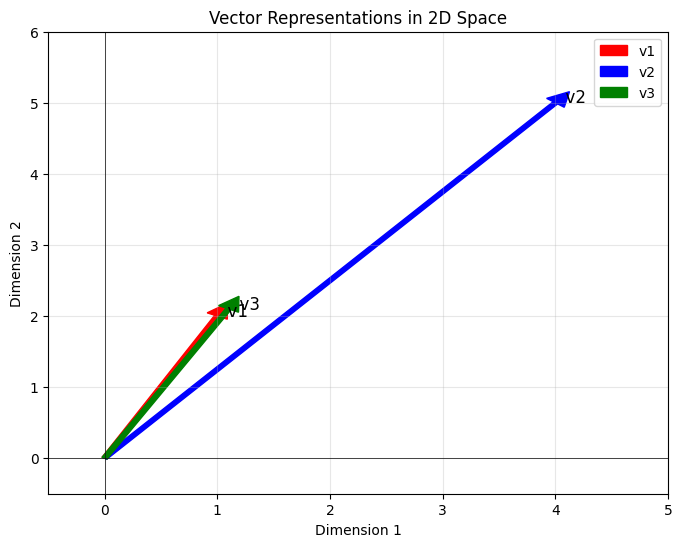

In [47]:
# Demonstrate different distance metrics
import numpy as np
import matplotlib.pyplot as plt

# Create sample vectors
v1 = np.array([1.0, 2.0, 3.0])
v2 = np.array([4.0, 5.0, 6.0])
v3 = np.array([1.1, 2.1, 3.0])

def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b)**2))

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def manhattan_distance(a, b):
    return np.sum(np.abs(a - b))

# Compare metrics
print("Vector 1:", v1)
print("Vector 2:", v2)
print("Vector 3:", v3)
print("\nComparing v1 and v2:")
print(f"Euclidean Distance: {euclidean_distance(v1, v2):.4f}")
print(f"Cosine Similarity: {cosine_similarity(v1, v2):.4f}")
print(f"Manhattan Distance: {manhattan_distance(v1, v2):.4f}")

print("\nComparing v1 and v3 (very similar):")
print(f"Euclidean Distance: {euclidean_distance(v1, v3):.4f}")
print(f"Cosine Similarity: {cosine_similarity(v1, v3):.4f}")
print(f"Manhattan Distance: {manhattan_distance(v1, v3):.4f}")

# Visualize in 2D
vectors_2d = np.array([[1, 2], [4, 5], [1.1, 2.1]])
labels = ['v1', 'v2', 'v3']
colors = ['red', 'blue', 'green']

plt.figure(figsize=(8, 6))
for i, (vec, label, color) in enumerate(zip(vectors_2d, labels, colors)):
    plt.arrow(0, 0, vec[0], vec[1], head_width=0.2, head_length=0.2, 
              fc=color, ec=color, label=label, width=0.05)
    plt.text(vec[0], vec[1], f'  {label}', fontsize=12)

plt.xlim(-0.5, 5)
plt.ylim(-0.5, 6)
plt.grid(True, alpha=0.3)
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.title('Vector Representations in 2D Space')
plt.legend()
plt.axhline(y=0, color='k', linewidth=0.5)
plt.axvline(x=0, color='k', linewidth=0.5)
plt.show()

## Image Embeddings with CNNs

Convolutional Neural Networks can extract meaningful feature representations (embeddings) from images.

### CNN Architecture for Embeddings

```mermaid
graph LR
    A[Input Image<br/>224×224×3] --> B[Conv Layers]
    B --> C[Pooling Layers]
    C --> D[Flatten]
    D --> E[Feature Vector<br/>Embedding]
    
    style A fill:#ffe6e6
    style E fill:#e6f3ff
```

### Transfer Learning for Image Embeddings

Using pre-trained models (ResNet, VGG, EfficientNet) trained on ImageNet:

1. **Remove Final Layer**: Use the penultimate layer as embedding
2. **Feature Extraction**: Extract features without fine-tuning
3. **Fine-tuning**: Optionally adapt to specific domain

### Embedding Extraction Points

Different layers capture different levels of abstraction:
- **Early layers**: Low-level features (edges, textures)
- **Middle layers**: Mid-level features (shapes, patterns)
- **Deep layers**: High-level semantic features

Example 1: Image Embeddings with ResNet50


w:\AIBookGitHubPrivate\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning:

The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.

w:\AIBookGitHubPrivate\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning:

Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.



Embedding dimension: 2048
Embeddings shape: (4, 2048)

Cosine Similarity Matrix:
        Red     Green   Blue    Yellow  
Red       1.0000  0.8797  0.6939  0.9008
Green     0.8797  1.0000  0.7233  0.8274
Blue      0.6939  0.7233  1.0000  0.6807
Yellow    0.9008  0.8274  0.6807  1.0000

Example 2: Multi-scale Embeddings from Different Layers
Embeddings shape: (4, 2048)

Cosine Similarity Matrix:
        Red     Green   Blue    Yellow  
Red       1.0000  0.8797  0.6939  0.9008
Green     0.8797  1.0000  0.7233  0.8274
Blue      0.6939  0.7233  1.0000  0.6807
Yellow    0.9008  0.8274  0.6807  1.0000

Example 2: Multi-scale Embeddings from Different Layers


w:\AIBookGitHubPrivate\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning:

The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.

w:\AIBookGitHubPrivate\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning:

Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.



Multi-scale embedding dimensions:
early   : torch.Size([1, 256])
mid     : torch.Size([1, 512])
late    : torch.Size([1, 1024])
deep    : torch.Size([1, 2048])

Example 3: Visualizing High-Dimensional Image Embeddings


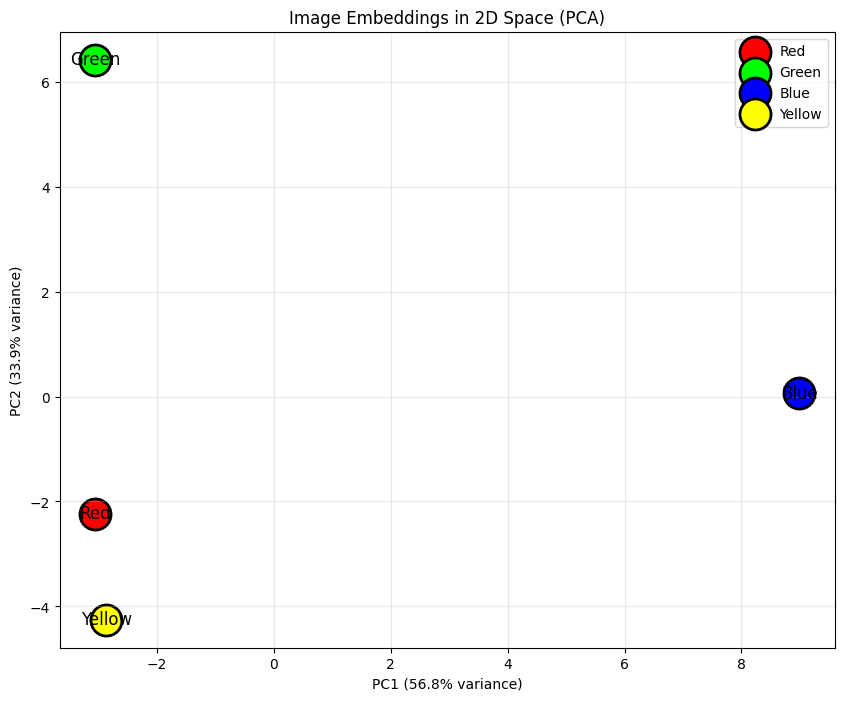

Total variance explained: 90.69%


In [48]:
# Image Embeddings using Pre-trained CNNs
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Example 1: Extract embeddings using ResNet
print("="*60)
print("Example 1: Image Embeddings with ResNet50")
print("="*60)

class ImageEmbedder(nn.Module):
    def __init__(self, model_name='resnet50', embedding_dim=2048):
        super().__init__()
        
        # Load pre-trained model
        if model_name == 'resnet50':
            base_model = models.resnet50(pretrained=True)
            # Remove the final classification layer
            self.encoder = nn.Sequential(*list(base_model.children())[:-1])
        elif model_name == 'resnet18':
            base_model = models.resnet18(pretrained=True)
            self.encoder = nn.Sequential(*list(base_model.children())[:-1])
            embedding_dim = 512
        
        self.embedding_dim = embedding_dim
        
        # Set to evaluation mode
        self.encoder.eval()
        
    def forward(self, x):
        with torch.no_grad():
            embedding = self.encoder(x)
            # Flatten the output
            embedding = embedding.view(embedding.size(0), -1)
        return embedding

# Create embedder
embedder = ImageEmbedder('resnet50')
print(f"Embedding dimension: {embedder.embedding_dim}")

# Image preprocessing
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

# Create sample images (random for demonstration)
def create_sample_image(color):
    """Create a simple colored image"""
    img = Image.new('RGB', (224, 224), color=color)
    return img

# Generate sample images
sample_images = [
    create_sample_image((255, 0, 0)),    # Red
    create_sample_image((0, 255, 0)),    # Green
    create_sample_image((0, 0, 255)),    # Blue
    create_sample_image((255, 255, 0)),  # Yellow
]

# Process and embed images
embeddings_list = []
for img in sample_images:
    # Preprocess
    img_tensor = preprocess(img).unsqueeze(0)
    
    # Get embedding
    embedding = embedder(img_tensor)
    embeddings_list.append(embedding.squeeze().numpy())

embeddings_array = np.array(embeddings_list)
print(f"Embeddings shape: {embeddings_array.shape}")

# Compute similarity matrix
from sklearn.metrics.pairwise import cosine_similarity
similarity_matrix = cosine_similarity(embeddings_array)

print("\nCosine Similarity Matrix:")
colors = ['Red', 'Green', 'Blue', 'Yellow']
print(f"{'':8}", end='')
for color in colors:
    print(f"{color:8}", end='')
print()
for i, color1 in enumerate(colors):
    print(f"{color1:8}", end='')
    for j in range(len(colors)):
        print(f"{similarity_matrix[i,j]:8.4f}", end='')
    print()

# Example 2: Multi-scale embeddings from different layers
print("\n" + "="*60)
print("Example 2: Multi-scale Embeddings from Different Layers")
print("="*60)

class MultiScaleEmbedder(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(pretrained=True)
        
        # Extract different layers
        self.layer1 = nn.Sequential(*list(resnet.children())[:5])  # Early features
        self.layer2 = nn.Sequential(*list(resnet.children())[5:6])  # Mid features
        self.layer3 = nn.Sequential(*list(resnet.children())[6:7])  # Late features
        self.layer4 = nn.Sequential(*list(resnet.children())[7:8])  # Deep features
        
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Set to evaluation mode
        self.eval()
        
    def forward(self, x):
        with torch.no_grad():
            # Extract features from different depths
            f1 = self.layer1(x)
            f2 = self.layer2(f1)
            f3 = self.layer3(f2)
            f4 = self.layer4(f3)
            
            # Pool and flatten each
            e1 = self.global_pool(f1).view(f1.size(0), -1)
            e2 = self.global_pool(f2).view(f2.size(0), -1)
            e3 = self.global_pool(f3).view(f3.size(0), -1)
            e4 = self.global_pool(f4).view(f4.size(0), -1)
            
            return {
                'early': e1,
                'mid': e2,
                'late': e3,
                'deep': e4
            }

multi_embedder = MultiScaleEmbedder()

# Get embeddings from different layers
sample_img = preprocess(sample_images[0]).unsqueeze(0)
multi_embeddings = multi_embedder(sample_img)

print("Multi-scale embedding dimensions:")
for layer_name, embedding in multi_embeddings.items():
    print(f"{layer_name:8}: {embedding.shape}")

# Example 3: Dimensionality Reduction of Image Embeddings
print("\n" + "="*60)
print("Example 3: Visualizing High-Dimensional Image Embeddings")
print("="*60)

from sklearn.decomposition import PCA

# Use PCA to reduce to 2D for visualization
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings_array)

plt.figure(figsize=(10, 8))
colors_rgb = [(1,0,0), (0,1,0), (0,0,1), (1,1,0)]
for i, (emb, color, label) in enumerate(zip(embeddings_2d, colors_rgb, colors)):
    plt.scatter(emb[0], emb[1], c=[color], s=500, label=label, edgecolors='black', linewidth=2)
    plt.annotate(label, (emb[0], emb[1]), fontsize=12, ha='center', va='center')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('Image Embeddings in 2D Space (PCA)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

## Image Embeddings

**Core Idea:** Use CNNs to extract semantic features from images, typically from intermediate layers.

### Why Embeddings Instead of Raw Pixels?

1. **Dimensionality:** 224×224×3 image = 150,528 dimensions → reduce to 512-2048
2. **Semantic meaning:** Pixels are low-level; embeddings capture objects, textures, scenes
3. **Transfer learning:** Embeddings from ImageNet generalize to new tasks

### Common Architectures

| Model | Embedding Layer | Dimensions | Use Case |
|-------|----------------|------------|----------|
| **ResNet-50** | `avgpool` before FC | 2048 | General-purpose vision |
| **VGG-16** | `fc6` or `fc7` | 4096 | Fine-grained classification |
| **EfficientNet** | Final pooling layer | 1280-2560 | Mobile/edge devices |
| **CLIP** | Joint text-image space | 512 | Cross-modal retrieval |

**References:**
- **He, K., et al. (2016).** "Deep Residual Learning for Image Recognition." *CVPR*.
- **Radford, A., et al. (2021).** "Learning Transferable Visual Models From Natural Language Supervision." *ICML* (CLIP).

### Applications

1. **Image similarity search:** Find visually similar products
2. **Face recognition:** Compare embeddings instead of raw images
3. **Zero-shot learning:** Match images to text descriptions (CLIP)

**Code Example:** The cell below extracts embeddings from ResNet-18's penultimate layer.

---

**Discussion:** Why extract embeddings from intermediate layers instead of the final classification layer? When would you use `layer3` vs. `avgpool`?

Example 1: Word Similarity Evaluation

Word Pair Similarities:
Pair                    Human  Embedding     Diff
--------------------------------------------------
king-queen               9.00       9.99     0.99
king-man                 7.00       9.87     2.87
queen-woman              7.00       9.83     2.83
man-woman                8.00       9.99     1.99
king-cat                 1.00       7.36     6.36
prince-princess          9.00       9.99     0.99
cat-dog                  7.00       9.98     2.98

Spearman Correlation: 0.9543 (p-value: 0.0008)


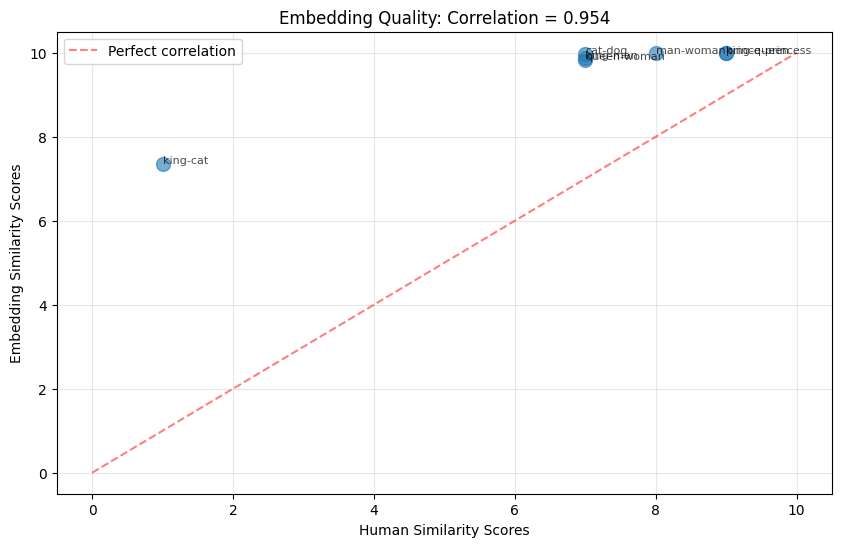


Example 2: Word Analogy Evaluation

Word Analogy Tests:
Analogy                                  Predicted         Similarity
----------------------------------------------------------------------
king:man :: queen:?                      ✓ woman               1.0000
prince:man :: princess:?                 ✓ woman               1.0000

Analogy Accuracy: 100.00% (2/2)

Example 3: Clustering Quality (Silhouette Score)
Silhouette Score: 0.7863
Interpretation:
  1.0  : Perfect clustering
  0.5+ : Good clustering
  0.0  : Overlapping clusters
  < 0  : Wrong clustering


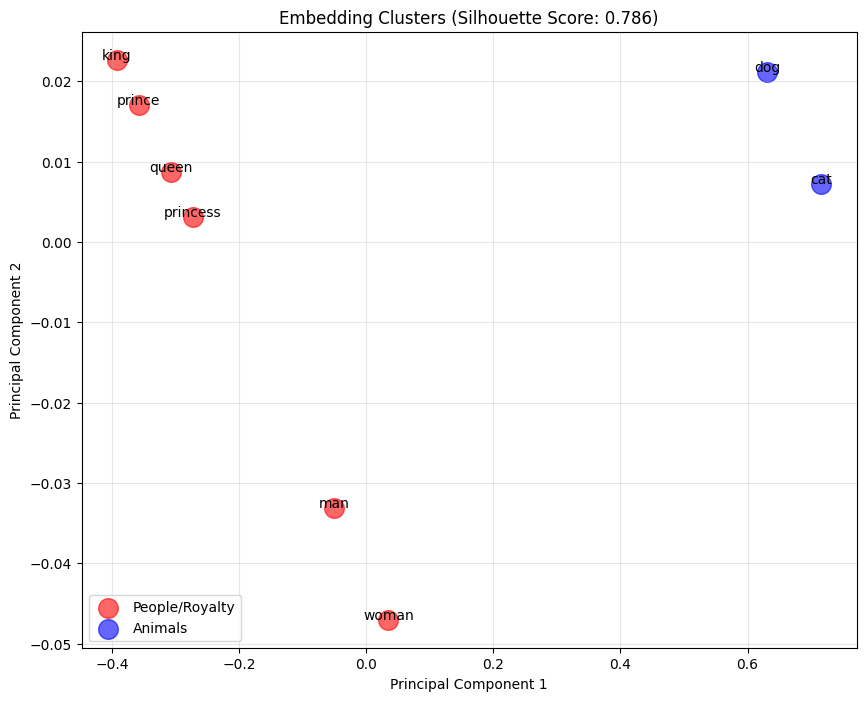


Example 4: Embedding Dimensionality Analysis
Dim   2: Error = 0.921524, Variance = 7.67%
Dim   5: Error = 0.821336, Variance = 17.71%
Dim  10: Error = 0.678853, Variance = 31.99%
Dim  20: Error = 0.457503, Variance = 54.16%
Dim  50: Error = 0.103465, Variance = 89.63%
Dim 100: Error = 0.000000, Variance = 100.00%


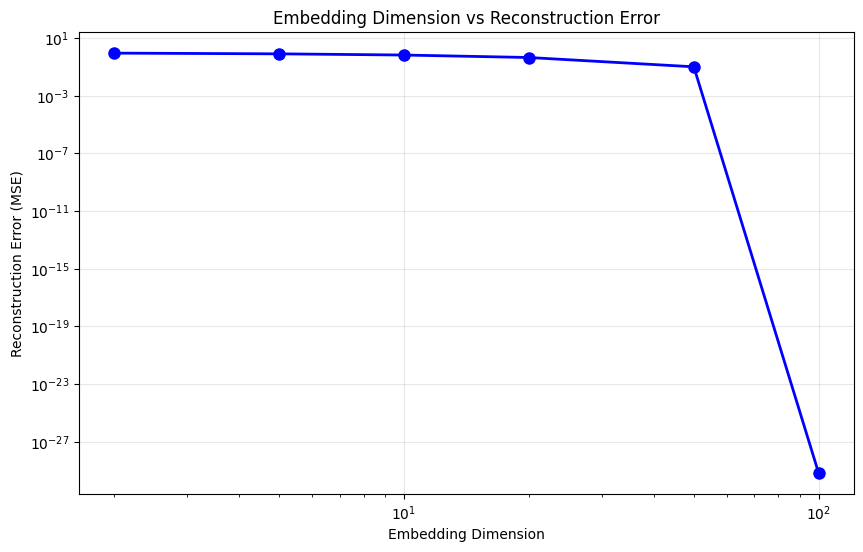


Conclusion: Higher dimensions preserve more information but increase computational cost


In [49]:
# Embedding Evaluation Examples
import numpy as np
from sklearn.metrics import silhouette_score
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

print("="*60)
print("Example 1: Word Similarity Evaluation")
print("="*60)

# Simulate word embeddings
word_to_embedding = {
    'king': np.array([0.9, 0.1, 0.8]),
    'queen': np.array([0.85, 0.15, 0.75]),
    'man': np.array([0.7, 0.3, 0.6]),
    'woman': np.array([0.65, 0.35, 0.55]),
    'prince': np.array([0.88, 0.12, 0.78]),
    'princess': np.array([0.83, 0.17, 0.73]),
    'cat': np.array([0.2, 0.8, 0.3]),
    'dog': np.array([0.25, 0.75, 0.35]),
}

def cosine_similarity_words(w1, w2, embeddings):
    v1 = embeddings[w1]
    v2 = embeddings[w2]
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

# Human similarity ratings (scale 0-10)
word_pairs_human = [
    (('king', 'queen'), 9.0),
    (('king', 'man'), 7.0),
    (('queen', 'woman'), 7.0),
    (('man', 'woman'), 8.0),
    (('king', 'cat'), 1.0),
    (('prince', 'princess'), 9.0),
    (('cat', 'dog'), 7.0),
]

# Compute embedding similarities
human_scores = []
embedding_scores = []

print("\nWord Pair Similarities:")
print(f"{'Pair':20} {'Human':>8} {'Embedding':>10} {'Diff':>8}")
print("-" * 50)

for (w1, w2), human_score in word_pairs_human:
    emb_sim = cosine_similarity_words(w1, w2, word_to_embedding)
    # Normalize to 0-10 scale
    emb_score = (emb_sim + 1) * 5  
    
    human_scores.append(human_score)
    embedding_scores.append(emb_score)
    
    print(f"{w1+'-'+w2:20} {human_score:8.2f} {emb_score:10.2f} {abs(human_score-emb_score):8.2f}")

# Compute correlation
correlation, p_value = spearmanr(human_scores, embedding_scores)
print(f"\nSpearman Correlation: {correlation:.4f} (p-value: {p_value:.4f})")

# Visualize
plt.figure(figsize=(10, 6))
plt.scatter(human_scores, embedding_scores, s=100, alpha=0.6)
for i, ((w1, w2), _) in enumerate(word_pairs_human):
    plt.annotate(f"{w1}-{w2}", (human_scores[i], embedding_scores[i]), 
                fontsize=8, alpha=0.7)
plt.plot([0, 10], [0, 10], 'r--', alpha=0.5, label='Perfect correlation')
plt.xlabel('Human Similarity Scores')
plt.ylabel('Embedding Similarity Scores')
plt.title(f'Embedding Quality: Correlation = {correlation:.3f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n" + "="*60)
print("Example 2: Word Analogy Evaluation")
print("="*60)

def solve_analogy(a, b, c, embeddings, top_k=1):
    """
    Solve analogy: a is to b as c is to ?
    Returns the word d such that: b - a + c ≈ d
    """
    v_a = embeddings[a]
    v_b = embeddings[b]
    v_c = embeddings[c]
    
    # Target vector
    target = v_b - v_a + v_c
    
    # Find closest word
    best_words = []
    for word, vec in embeddings.items():
        if word not in [a, b, c]:
            similarity = np.dot(target, vec) / (np.linalg.norm(target) * np.linalg.norm(vec))
            best_words.append((word, similarity))
    
    best_words.sort(key=lambda x: x[1], reverse=True)
    return best_words[:top_k]

# Test analogies
analogies = [
    ('king', 'man', 'queen', 'woman'),
    ('prince', 'man', 'princess', 'woman'),
]

print("\nWord Analogy Tests:")
print(f"{'Analogy':40} {'Predicted':15} {'Similarity':>12}")
print("-" * 70)

correct = 0
total = len(analogies)

for a, b, c, expected_d in analogies:
    results = solve_analogy(a, b, c, word_to_embedding)
    predicted_d, similarity = results[0]
    
    is_correct = predicted_d == expected_d
    correct += is_correct
    
    analogy_str = f"{a}:{b} :: {c}:?"
    result_str = f"✓ {predicted_d}" if is_correct else f"✗ {predicted_d} (expected {expected_d})"
    
    print(f"{analogy_str:40} {result_str:15} {similarity:12.4f}")

accuracy = correct / total
print(f"\nAnalogy Accuracy: {accuracy:.2%} ({correct}/{total})")

print("\n" + "="*60)
print("Example 3: Clustering Quality (Silhouette Score)")
print("="*60)

# Create embeddings and labels
all_words = list(word_to_embedding.keys())
all_embeddings = np.array([word_to_embedding[w] for w in all_words])

# Define true clusters
labels = np.array([
    0, 0, 0, 0, 0, 0,  # royalty/people: king, queen, man, woman, prince, princess
    1, 1,              # animals: cat, dog
])

# Compute silhouette score
silhouette_avg = silhouette_score(all_embeddings, labels)
print(f"Silhouette Score: {silhouette_avg:.4f}")
print("Interpretation:")
print("  1.0  : Perfect clustering")
print("  0.5+ : Good clustering")
print("  0.0  : Overlapping clusters")
print("  < 0  : Wrong clustering")

# Visualize clusters
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(all_embeddings)

plt.figure(figsize=(10, 8))
colors = ['red', 'blue']
cluster_names = ['People/Royalty', 'Animals']

for i, cluster_label in enumerate(np.unique(labels)):
    mask = labels == cluster_label
    plt.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], 
               c=colors[i], label=cluster_names[i], s=200, alpha=0.6)
    
    for j, word in enumerate(np.array(all_words)[mask]):
        plt.annotate(word, (embeddings_2d[mask][j, 0], embeddings_2d[mask][j, 1]),
                    fontsize=10, ha='center')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title(f'Embedding Clusters (Silhouette Score: {silhouette_avg:.3f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n" + "="*60)
print("Example 4: Embedding Dimensionality Analysis")
print("="*60)

# Create embeddings of different dimensions
dimensions = [2, 5, 10, 20, 50, 100]
reconstruction_errors = []

# Original data (simulate high-dimensional data)
np.random.seed(42)
original_data = np.random.randn(100, 100)

for dim in dimensions:
    pca = PCA(n_components=dim)
    reduced = pca.fit_transform(original_data)
    reconstructed = pca.inverse_transform(reduced)
    error = np.mean((original_data - reconstructed) ** 2)
    reconstruction_errors.append(error)
    variance_explained = pca.explained_variance_ratio_.sum()
    
    print(f"Dim {dim:3d}: Error = {error:.6f}, Variance = {variance_explained:.2%}")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(dimensions, reconstruction_errors, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Embedding Dimension')
plt.ylabel('Reconstruction Error (MSE)')
plt.title('Embedding Dimension vs Reconstruction Error')
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.yscale('log')
plt.show()

print("\nConclusion: Higher dimensions preserve more information but increase computational cost")

## Stock Embedding

In [50]:
# Install required packages if not already installed
%pip install yfinance plotly scikit-learn

import yfinance as yf
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import plotly.express as px

tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA", 
           "NVDA", "AVGO", "AMD", "QCOM", "IBM", 
           "IONQ", "RGTI", "PLTR", "ACHR", "RDW",
           "BKSY", "VUZI", "NNDM", "SNDL", "TLRY"]

# Download closing prices for each ticker
data = {}
for ticker in tickers:
    stock = yf.Ticker(ticker)
    df = stock.history(period="1y")
    data[ticker] = df["Close"]

# Combine data into a single DataFrame (dates as rows, tickers as columns)
df_stocks = pd.DataFrame(data)
df_stocks = df_stocks.ffill().dropna()  # simple cleaning
print(df_stocks.head())

# Scale each column (stock) independently
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df_stocks)

# Transpose so each row represents one stock’s time series
# df_stocks.shape: (time_steps, tickers) -> (tickers, time_steps)
data_scaled = data_scaled.T

# Convert to PyTorch tensor
data_tensor = torch.tensor(data_scaled, dtype=torch.float32)
print("Data tensor shape (stocks, time_series_length):", data_tensor.shape)


Note: you may need to restart the kernel to use updated packages.


w:\AIBookGitHubPrivate\.venv\Scripts\python.exe: No module named pip


                                 AAPL        MSFT       GOOGL        AMZN  \
Date                                                                        
2024-10-08 00:00:00-04:00  224.724136  411.619781  163.658264  182.720001   
2024-10-09 00:00:00-04:00  228.476669  414.349243  161.149338  185.169998   
2024-10-10 00:00:00-04:00  227.978973  412.741302  161.368362  186.649994   
2024-10-11 00:00:00-04:00  226.495880  413.217743  162.523285  188.820007   
2024-10-14 00:00:00-04:00  230.228516  416.016724  164.235718  187.539993   

                                 TSLA        NVDA        AVGO         AMD  \
Date                                                                        
2024-10-08 00:00:00-04:00  244.500000  132.851898  178.974670  172.800003   
2024-10-09 00:00:00-04:00  241.050003  132.611969  184.143967  171.020004   
2024-10-10 00:00:00-04:00  238.770004  134.771347  183.886475  164.179993   
2024-10-11 00:00:00-04:00  217.800003  134.761368  179.717361  167.889999  

In [51]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, embedding_dim=3):
        super(Autoencoder, self).__init__()
        # Encoder: compress input into embedding_dim
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, embedding_dim)
        )
        # Decoder: reconstruct input from embedding
        self.decoder = nn.Sequential(
            nn.Linear(embedding_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )
        
    def forward(self, x):
        z = self.encoder(x)
        reconstructed = self.decoder(z)
        return reconstructed, z

input_dim = data_tensor.shape[1]  # number of time steps
embedding_dim = 3
model = Autoencoder(input_dim, embedding_dim)
print(model)

# Training parameters
epochs = 1000
learning_rate = 1e-3

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
model.train()
for epoch in range(epochs):
    optimizer.zero_grad()
    reconstructed, _ = model(data_tensor)
    loss = criterion(reconstructed, data_tensor)
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 100 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")

# Evaluation
model.eval()
with torch.no_grad():
    _, embeddings = model(data_tensor)
embeddings = embeddings.numpy()
print("Embeddings shape:", embeddings.shape)

# Create a DataFrame for plotting
df_embeddings = pd.DataFrame(embeddings, columns=["Dim1", "Dim2", "Dim3"])
df_embeddings["Ticker"] = tickers  # Make sure the order matches

# Plot using Plotly
fig = px.scatter_3d(df_embeddings, x="Dim1", y="Dim2", z="Dim3", text="Ticker", title="3D Stock Embeddings (Autoencoder)", height=1000)
fig.show()


Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=250, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=3, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=3, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=250, bias=True)
  )
)
Epoch 100/1000, Loss: 0.037402
Epoch 100/1000, Loss: 0.037402
Epoch 200/1000, Loss: 0.019058
Epoch 200/1000, Loss: 0.019058
Epoch 300/1000, Loss: 0.010308
Epoch 300/1000, Loss: 0.010308
Epoch 400/1000, Loss: 0.005315
Epoch 400/1000, Loss: 0.005315
Epoch 500/1000, Loss: 0.003838
Epoch 500/1000, Loss: 0.003838
Epoch 600/1000, Loss: 0.003088
Epoch 600/1000, Loss: 0.003088
Epoch 700/1000, Loss: 0.002489
Epoch 700/1000, Loss: 0.002489
Epoch 800/1000, Loss: 0.002082
Epoch 800/1000, Loss: 0.002082
Epoch 9

# References

## Foundational Papers

### Word Embeddings & Classical Methods
1. **Mikolov, T., et al. (2013).** "Efficient Estimation of Word Representations in Vector Space." *arXiv:1301.3781*. [Original Word2Vec paper]
2. **Mikolov, T., et al. (2013).** "Distributed Representations of Words and Phrases and their Compositionality." *NIPS 2013*. [Negative sampling, hierarchical softmax]
3. **Pennington, J., et al. (2014).** "GloVe: Global Vectors for Word Representation." *EMNLP 2014*. [Matrix factorization approach]
4. **Bojanowski, P., et al. (2017).** "Enriching Word Vectors with Subword Information." *TACL 2017*. [FastText]
5. **Peters, M.E., et al. (2018).** "Deep Contextualized Word Representations." *NAACL 2018*. [ELMo - first contextual embeddings]

### Transformer & Attention-Based Embeddings
6. **Vaswani, A., et al. (2017).** "Attention Is All You Need." *NIPS 2017*. [Original Transformer architecture]
7. **Devlin, J., et al. (2019).** "BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding." *NAACL 2019*. [BERT]
8. **Radford, A., et al. (2019).** "Language Models are Unsupervised Multitask Learners." *OpenAI*. [GPT-2]
9. **Dosovitskiy, A., et al. (2021).** "An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale." *ICLR 2021*. [Vision Transformer]

### Image & Multimodal Embeddings
10. **He, K., et al. (2016).** "Deep Residual Learning for Image Recognition." *CVPR 2016*. [ResNet for image features]
11. **Radford, A., et al. (2021).** "Learning Transferable Visual Models From Natural Language Supervision." *ICML 2021*. [CLIP - joint text-image embeddings]
12. **Simonyan, K., & Zisserman, A. (2015).** "Very Deep Convolutional Networks for Large-Scale Image Recognition." *ICLR 2015*. [VGG]

### Generative & Probabilistic Embeddings
13. **Kingma, D.P., & Welling, M. (2014).** "Auto-Encoding Variational Bayes." *ICLR 2014*. [Variational Autoencoders]
14. **Goodfellow, I., et al. (2014).** "Generative Adversarial Nets." *NIPS 2014*. [GANs]
15. **Ronneberger, O., et al. (2015).** "U-Net: Convolutional Networks for Biomedical Image Segmentation." *MICCAI 2015*. [U-Net architecture]

### Specialized Neural Embeddings
16. **Kipf, T.N., & Welling, M. (2017).** "Semi-Supervised Classification with Graph Convolutional Networks." *ICLR 2017*. [Graph Neural Networks]
17. **Chen, T., et al. (2020).** "A Simple Framework for Contrastive Learning of Visual Representations." *ICML 2020*. [SimCLR - contrastive learning]
18. **Bromley, J., et al. (1994).** "Signature Verification using a 'Siamese' Time Delay Neural Network." *NIPS 1994*. [Siamese networks]

### Financial Applications
19. **Heaton, J.B., et al. (2017).** "Deep Learning for Finance: Deep Portfolios." *Applied Stochastic Models in Business and Industry*. [Neural networks in finance]
20. **Gu, S., et al. (2020).** "Empirical Asset Pricing via Machine Learning." *Review of Financial Studies*. [ML applications in asset pricing]

---

## Key Datasets

- **ImageNet**: Large-scale image database for computer vision research
- **Common Crawl**: Web crawl data used for training large language models  
- **MS COCO**: Object detection, segmentation and captioning dataset
- **WikiText**: Collection of high-quality Wikipedia articles for language modeling
- **Yahoo Finance API**: Historical stock price data for financial embeddings

---

## Online Resources & Tools

### Libraries & Frameworks
- **Hugging Face Transformers**: State-of-the-art transformer models and embeddings
- **Sentence-Transformers**: Specialized library for sentence embeddings
- **PyTorch/TensorFlow**: Deep learning frameworks for custom embedding implementations
- **Gensim**: Traditional word embedding implementations (Word2Vec, FastText, GloVe)

### Pre-trained Models
- **BERT/RoBERTa**: Contextual text embeddings
- **CLIP**: Joint text-image embeddings  
- **Word2Vec/GloVe**: Pre-trained word vectors
- **ResNet/EfficientNet**: Pre-trained image feature extractors

### Visualization Tools
- **t-SNE/UMAP**: Dimensionality reduction for embedding visualization
- **TensorBoard**: Neural network training visualization
- **Plotly/Matplotlib**: Interactive plotting for embedding analysis

---

## Further Reading

### Books
- **Jurafsky, D., & Martin, J.H.** "Speech and Language Processing" (3rd ed.) - Chapter on embeddings
- **Goodfellow, I., et al.** "Deep Learning" - Mathematical foundations of neural networks
- **Chollet, F.** "Deep Learning with Python" - Practical implementation guide

### Survey Papers
- **Qiu, X., et al. (2020).** "Pre-trained Models for Natural Language Processing: A Survey." *Science China Technological Sciences*.
- **Hamilton, W.L., et al. (2017).** "Representation Learning on Graphs: Methods and Applications." *IEEE Data Engineering Bulletin*.

### Courses & Tutorials
- **CS224N (Stanford)**: Natural Language Processing with Deep Learning
- **CS231N (Stanford)**: Convolutional Neural Networks for Visual Recognition  
- **Fast.ai**: Practical Deep Learning for Coders

# Practice Questions & Exercises

## Conceptual Questions

### 1. Foundation Concepts
**Q1.1:** Why do we use embeddings instead of one-hot encodings? List at least 3 reasons.

**Q1.2:** Explain the trade-off between embedding dimension and model performance. What happens if dimensions are too low? Too high?

**Q1.3:** What is the difference between *static* embeddings (Word2Vec, GloVe) and *contextual* embeddings (BERT, ELMo)? Give an example where this matters.

### 2. Mathematical Understanding
**Q2.1:** Given the mathematical constraint for embeddings $f: X \rightarrow \mathbb{R}^n$, explain why injectivity is important and what happens when it's violated.

**Q2.2:** Calculate the cosine similarity between vectors $[1, 2, 3]$ and $[2, 4, 6]$. What does this result tell us about their relationship?

**Q2.3:** In the famous Word2Vec analogy $\vec{king} - \vec{man} + \vec{woman} \approx \vec{queen}$, what mathematical property of the embedding space makes this work?

### 3. Architecture Decisions
**Q3.1:** You're building embeddings for medical images (X-rays). Should you use Dense layers, U-Net, or Transformer architecture? Justify your choice.

**Q3.2:** For the stock embedding example, why did we use an autoencoder instead of directly applying PCA to the price data?

**Q3.3:** When would you choose a Siamese network over a standard CNN for image embeddings?

---

## Coding Challenges

### Easy (Implementation Practice)

**Exercise E1: Distance Metrics**
```python
# Implement and compare different distance metrics
import numpy as np

def euclidean_distance(v1, v2):
    # TODO: Implement Euclidean distance
    pass

def cosine_similarity(v1, v2):
    # TODO: Implement cosine similarity
    pass

def manhattan_distance(v1, v2):
    # TODO: Implement Manhattan distance
    pass

# Test with vectors: [1, 2, 3] and [4, 5, 6]
```

**Exercise E2: Embedding Lookup**
```python
# Create a simple embedding layer
import torch.nn as nn

vocab_size = 1000
embedding_dim = 128

# TODO: Create embedding layer
# TODO: Create random input indices
# TODO: Get embeddings and print shape
```

### Intermediate (Application Building)

**Exercise I1: Text Classification with Embeddings**
```python
# Build a sentiment classifier using pre-trained embeddings
# 1. Load pre-trained Word2Vec/GloVe embeddings
# 2. Create document embeddings (average word embeddings)
# 3. Train a classifier on IMDB movie reviews
# 4. Compare performance with and without pre-trained embeddings
```

**Exercise I2: Image Similarity Search**
```python
# Build an image similarity search engine
# 1. Use pre-trained ResNet to extract image embeddings
# 2. Build a nearest neighbors index
# 3. Given a query image, return top-5 most similar images
# 4. Visualize results
```

**Exercise I3: Custom Autoencoder**
```python
# Modify the stock autoencoder for different data
# 1. Use cryptocurrency price data instead of stocks
# 2. Experiment with different embedding dimensions (2D, 5D, 10D)
# 3. Add regularization (dropout, L2)
# 4. Compare clustering quality across dimensions
```

### Advanced (Research-Level)

**Exercise A1: Multimodal Embeddings**
```python
# Create embeddings that work for both text and images
# 1. Implement a simple version of CLIP
# 2. Use contrastive loss to align text and image embeddings
# 3. Test on image-caption datasets
# 4. Evaluate zero-shot classification performance
```

**Exercise A2: Graph Embeddings**
```python
# Implement node embeddings for social networks
# 1. Use NetworkX to create a graph dataset
# 2. Implement node2vec or GraphSAGE
# 3. Visualize embeddings in 2D
# 4. Predict missing edges using embedding similarity
```

**Exercise A3: Temporal Embeddings**
```python
# Create time-aware embeddings for dynamic data
# 1. Extend the stock autoencoder to handle multiple time windows
# 2. Add LSTM layers to capture temporal dependencies
# 3. Predict future embedding trajectories
# 4. Analyze how embeddings evolve over time
```

---

## Critical Thinking Questions

### 1. Bias and Fairness
**Q1:** Word embeddings often exhibit gender and racial biases (e.g., "programmer" closer to "man" than "woman"). How could you detect and mitigate these biases?

**Q2:** In the stock embedding example, what biases might be present? How could sector or market cap bias affect the embeddings?

### 2. Evaluation and Validation
**Q3:** How would you evaluate whether stock embeddings are "good"? Design 3 different evaluation metrics.

**Q4:** For image embeddings, when is cosine similarity more appropriate than Euclidean distance? When might the opposite be true?

### 3. Real-World Applications
**Q5:** You're building a recommendation system. Users have both demographic features (age, location) and behavioral features (click history). How would you combine these into a single embedding?

**Q6:** In medical imaging, how would you ensure that embeddings learned from one hospital generalize to other hospitals with different equipment/protocols?

---

## Debugging Scenarios

### Scenario 1: Collapsed Embeddings
Your autoencoder converges quickly but all embeddings are nearly identical.

**Debug Questions:**
- What could cause this?
- How would you detect it?
- What solutions would you try?

### Scenario 2: Poor Clustering
Your word embeddings show low correlation with human similarity judgments.

**Debug Questions:**
- What evaluation metrics would you check?
- How could you improve the embeddings?
- What hyperparameters would you tune?

### Scenario 3: Transfer Learning Failure
Pre-trained image embeddings work poorly on your medical imaging task.

**Debug Questions:**
- Why might this happen?
- How would you adapt the embeddings?
- What alternative approaches could you try?

---

## Research Extensions

### 1. Novel Architectures
- Implement hybrid CNN-Transformer embeddings
- Create embeddings that explicitly model uncertainty
- Design embeddings for graphs with temporal dynamics

### 2. Evaluation Metrics
- Develop new metrics for embedding quality
- Study embedding stability across different initializations
- Create benchmarks for domain-specific embeddings

### 3. Applications
- Apply embeddings to new domains (audio, sensor data, genomics)
- Study embeddings for privacy-preserving machine learning
- Explore embeddings for few-shot and zero-shot learning

---

## Solutions Available

📝 **Note**: Sample solutions and hints for these exercises are available in the course repository. Try the exercises first before checking solutions!

🔍 **Self-Assessment**: Use the provided rubrics to evaluate your implementations and understanding.

🤝 **Discussion**: Join the course forum to discuss approaches and compare results with classmates.